<a href="https://colab.research.google.com/github/MIL-Project2/DR-DT/blob/main/Occupancy_Prediction_Ver1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
# 1. Set your user info (Git is already installed!)
!git config --global user.email "jwas0006@student.monash.edu"
!git config --global user.name "MIL-Project2"

# 2. Clone your repo (if you haven't already)
!git clone https://github.com/MIL-Project2/DR-DT.git
%cd DR-DT

# 3. Make your changes or add new files...

# 4. Push back to GitHub
!git add .
!git commit -m "Updated from Colab"

# 5. Push using your Personal Access Token (paste it when prompted for a password)
!git push

Cloning into 'DR-DT'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 52 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 1.72 MiB | 9.54 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/DR-DT/DR-DT/DR-DT/DR-DT/DR-DT/DR-DT/DR-DT/DR-DT/DR-DT
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [69]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print("All libraries imported successfully.")

All libraries imported successfully.


In [70]:
df = pd.read_csv('Occupancy-Prediction_Generated_Ver_1.1.csv', delimiter=',')

In [71]:
# ── Missing Values, Data Types & Duplicates ──────────────────────────────────
print("=== DATA AUDIT REPORT ===")
column_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(column_info)
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nStatistical Summary:")
display(df.describe().round(2))

=== DATA AUDIT REPORT ===


,Data Type,Non-Null Count,Missing Values,Missing (%)
timestamp,object,1000,0,0.0
deviceid,int64,1000,0,0.0
floorspaceid,object,1000,0,0.0
headcount,int64,1000,0,0.0
temperature,float64,1000,0,0.0
humidity,float64,1000,0,0.0
co2,float64,1000,0,0.0



Duplicate Rows: 0

Statistical Summary:


,deviceid,headcount,temperature,humidity,co2
count,1000.0,1000.00,1000.00,1000.00,1000.00
mean,56923747.0,1.42,20.59,58.47,457.72
std,0.0,2.63,1.78,5.51,72.04
min,56923747.0,0.00,17.24,42.73,317.59
25%,56923747.0,0.00,18.90,54.14,403.22
50%,56923747.0,0.00,20.53,58.47,436.76
75%,56923747.0,2.00,22.32,62.52,507.63
max,56923747.0,15.00,23.85,73.22,666.50


## **Exploratory Data Analysis (EDA)**

This section consolidates and extends the EDA. The analysis is structured around two research questions:

- **Q1:** What is the distribution of the target variable “headcount"?
- **Q2:** Which numerical features are most strongly correlated with “headcount”?

### **The distribution of the target variable “headcount"**

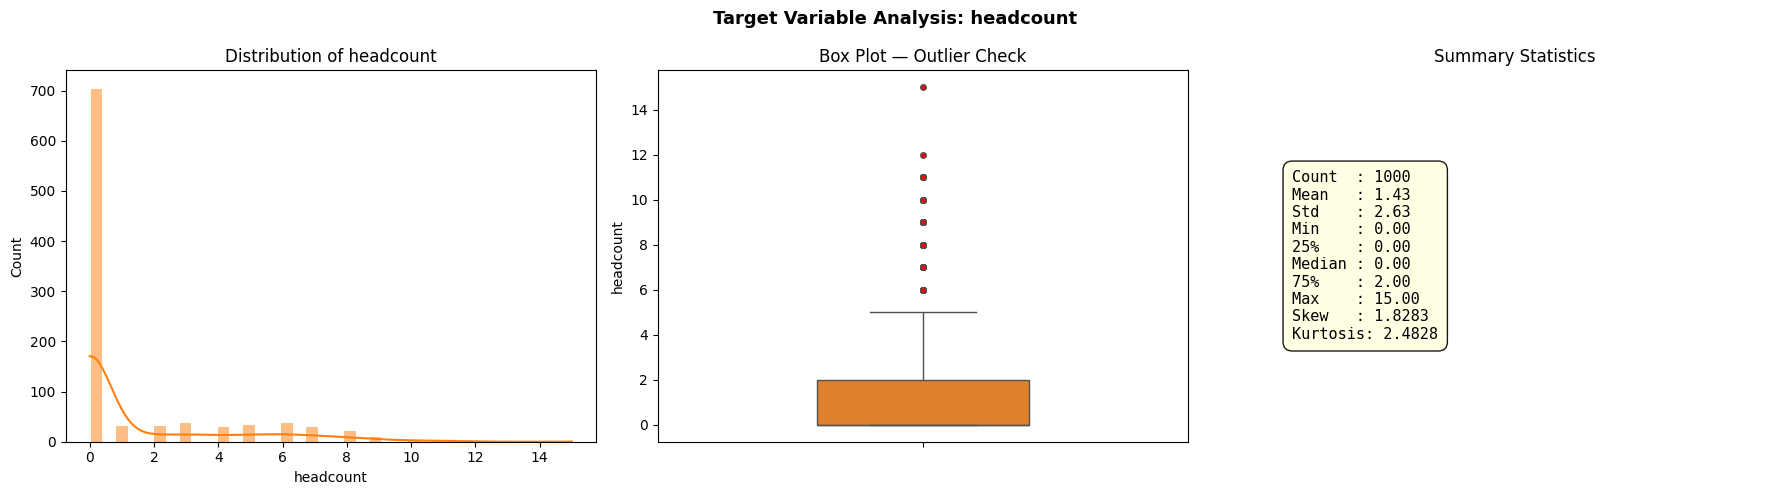

Skewness : 1.8283  (|skew| < 0.5 = approx. normal)
Kurtosis : 2.4828
IQR-based outliers : 120 (12.0%)


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
sns.histplot(df['headcount'], kde=True, ax=axes[0], color='tab:orange', edgecolor='white')
axes[0].set_title('Distribution of headcount')
axes[0].set_xlabel('headcount'); axes[0].set_ylabel('Count')

# Box plot — outlier check
sns.boxplot(y=df['headcount'], ax=axes[1], color='tab:orange', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[1].set_title('Box Plot — Outlier Check')
axes[1].set_ylabel('headcount')

# Summary statistics panel
desc = df['headcount'].describe()
lines = [f"Count  : {desc['count']:.0f}",
         f"Mean   : {desc['mean']:.2f}",
         f"Std    : {desc['std']:.2f}",
         f"Min    : {desc['min']:.2f}",
         f"25%    : {desc['25%']:.2f}",
         f"Median : {desc['50%']:.2f}",
         f"75%    : {desc['75%']:.2f}",
         f"Max    : {desc['max']:.2f}",
         f"Skew   : {df['headcount'].skew():.4f}",
         f"Kurtosis: {df['headcount'].kurtosis():.4f}"]
axes[2].axis('off')
axes[2].text(0.08, 0.5, '\n'.join(lines), transform=axes[2].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.9))
axes[2].set_title('Summary Statistics')

plt.suptitle('Target Variable Analysis: headcount', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Skewness : {df['headcount'].skew():.4f}  (|skew| < 0.5 = approx. normal)")
print(f"Kurtosis : {df['headcount'].kurtosis():.4f}")
q1, q3 = df['headcount'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['headcount'] < q1 - 1.5*iqr) | (df['headcount'] > q3 + 1.5*iqr)]
print(f"IQR-based outliers : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

### **Numerical features are most strongly correlated with “headcount”**

Pearson Correlation with Headcount (sorted by absolute value):
             Correlation
co2               0.8365
humidity          0.0560
temperature      -0.0459


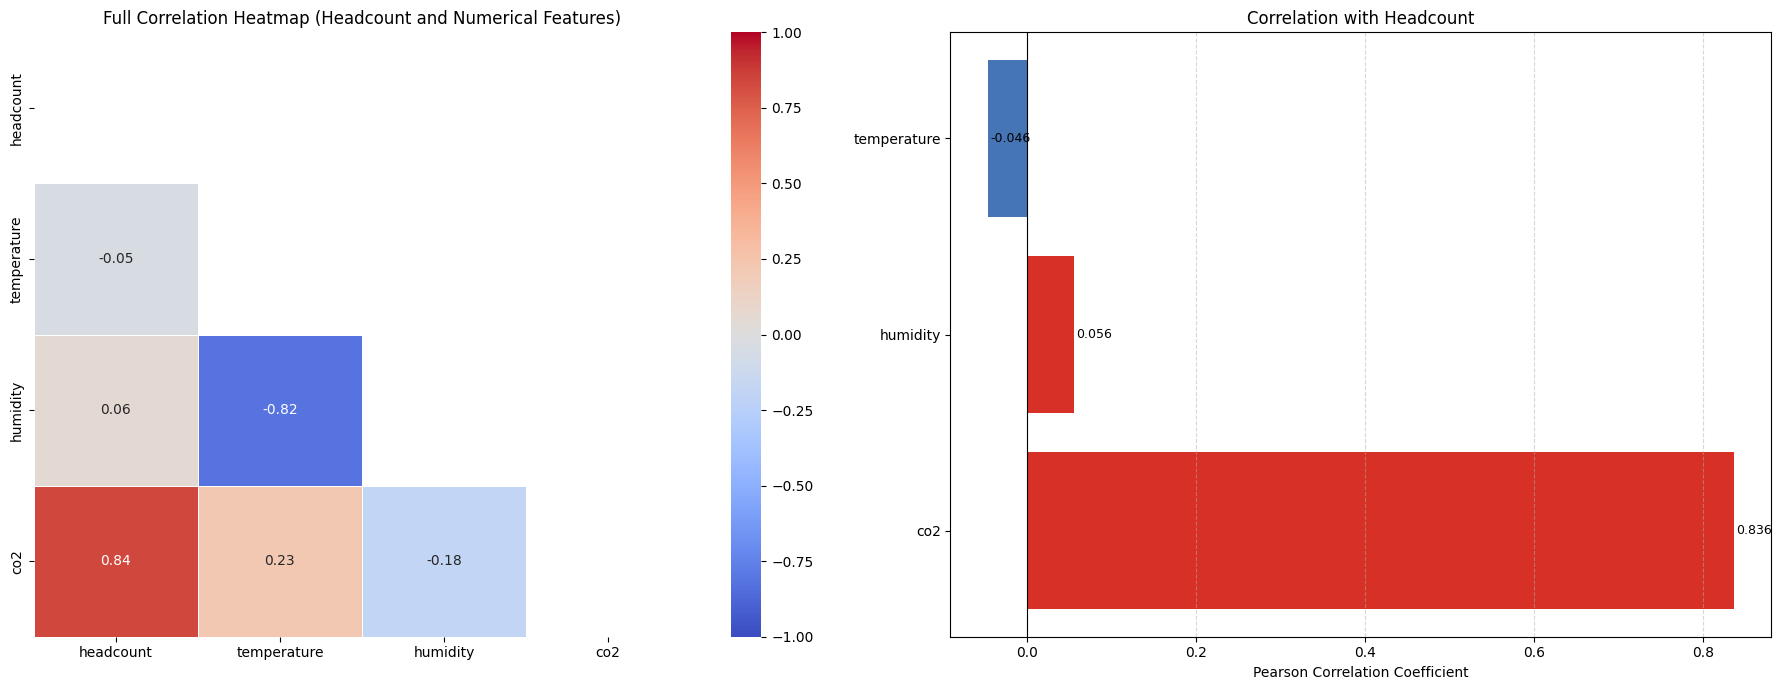

In [73]:
import numpy as np
# Identify numerical features relevant for correlation with 'headcount'
numerical_features = [
    'temperature', 'humidity', 'co2'
]

# Ensure 'headcount' is included for correlation calculation
cols_for_corr = ['headcount'] + numerical_features

# Calculate correlation matrix
corr_matrix_headcount = df[cols_for_corr].corr()

# Correlation with headcount (sorted by absolute value)
headcount_corr = corr_matrix_headcount['headcount'].drop('headcount').sort_values(key=abs, ascending=False)
print("Pearson Correlation with Headcount (sorted by absolute value):")
print(headcount_corr.to_frame('Correlation').round(4))

# Visualize correlations with heatmap and bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap (only for the selected numerical features and headcount)
mask = np.triu(np.ones_like(corr_matrix_headcount, dtype=bool))
sns.heatmap(corr_matrix_headcount, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Full Correlation Heatmap (Headcount and Numerical Features)', fontsize=12)

# Bar chart of correlations with headcount
colors_headcount = ['#d73027' if v > 0 else '#4575b4' for v in headcount_corr.values]
axes[1].barh(headcount_corr.index, headcount_corr.values, color=colors_headcount)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Headcount', fontsize=12)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(headcount_corr.values):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Data Cleaning & Preprocessing**

This section outlines the data cleaning and preprocessing steps necessary to prepare the `df` DataFrame for machine learning tasks. Building upon the initial data audit and EDA, this stage focuses on:

1.  **Timestamp Conversion**: Converting the `timestamp` column to datetime objects and extracting useful time-based features (e.g., `hour_of_day`, `day_of_week`) that might influence occupancy.
2.  **Feature Engineering**: Adding `occupancy_lag_5min`,	`occupancy_lag_10min`,	`occupancy_lag_15min`,	`occupancy_rolling_15min`,	`co2_rolling_15min`,	`temperature_rolling_15min`.
3.  **Outlier Strategy**: Deciding on an approach to handle the outliers identified in the `headcount` target variable and other numerical features.
4.  **Feature Scaling**: Applying appropriate scaling techniques to numerical features to ensure they are on a comparable scale for various machine learning algorithms.

### **Timestamp Conversion**

In [74]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%m/%d/%y %H:%M')
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.strftime('%A') # Convert to full day name
display(df.head())

,timestamp,deviceid,floorspaceid,headcount,temperature,humidity,co2,hour_of_day,day_of_week
0,2026-01-01 00:00:00,56923747,9f902aab,0,21.85,60.12,439.19,0,Thursday
1,2026-01-01 00:15:00,56923747,9f902aab,0,21.91,53.50,396.90,0,Thursday
2,2026-01-01 00:30:00,56923747,9f902aab,0,21.29,54.04,384.69,0,Thursday
3,2026-01-01 00:45:00,56923747,9f902aab,0,21.32,57.06,407.11,0,Thursday
4,2026-01-01 01:00:00,56923747,9f902aab,0,21.43,54.62,458.54,1,Thursday


### **Feature Engineering**

In [75]:
# Sort by timestamp to ensure correct lag and rolling calculations
df = df.sort_values(by='timestamp').reset_index(drop=True)

# Calculate lag features for 'headcount' (occupancy)
df['occupancy_lag_5min'] = df['headcount'].shift(1)  # Assuming 5-minute intervals
df['occupancy_lag_10min'] = df['headcount'].shift(2)
df['occupancy_lag_15min'] = df['headcount'].shift(3)

# Calculate rolling features. For a 15-minute window with 5-minute intervals, this is a 3-period window.
# min_periods=1 allows calculation even with fewer than 3 values at the start.
df['occupancy_rolling_15min'] = df['headcount'].rolling(window=3, min_periods=1).mean()
df['co2_rolling_15min'] = df['co2'].rolling(window=3, min_periods=1).mean()
df['temperature_rolling_15min'] = df['temperature'].rolling(window=3, min_periods=1).mean()

display(df.head())

,timestamp,deviceid,floorspaceid,headcount,temperature,humidity,co2,hour_of_day,day_of_week,occupancy_lag_5min,occupancy_lag_10min,occupancy_lag_15min,occupancy_rolling_15min,co2_rolling_15min,temperature_rolling_15min
0,2026-01-01 00:00:00,56923747,9f902aab,0,21.85,60.12,439.19,0,Thursday,NaN,NaN,NaN,0.0,439.190000,21.850000
1,2026-01-01 00:15:00,56923747,9f902aab,0,21.91,53.50,396.90,0,Thursday,0.0,NaN,NaN,0.0,418.045000,21.880000
2,2026-01-01 00:30:00,56923747,9f902aab,0,21.29,54.04,384.69,0,Thursday,0.0,0.0,NaN,0.0,406.926667,21.683333
3,2026-01-01 00:45:00,56923747,9f902aab,0,21.32,57.06,407.11,0,Thursday,0.0,0.0,0.0,0.0,396.233333,21.506667
4,2026-01-01 01:00:00,56923747,9f902aab,0,21.43,54.62,458.54,1,Thursday,0.0,0.0,0.0,0.0,416.780000,21.346667


### **Outlier Strategy**

In [76]:
# Capping outliers for 'headcount' using the 1st and 99th percentiles
lower_bound = df['headcount'].quantile(0.01)
upper_bound = df['headcount'].quantile(0.99)

df['headcount'] = np.where(df['headcount'] < lower_bound, lower_bound,
                           np.where(df['headcount'] > upper_bound, upper_bound, df['headcount']))

print(f"'headcount' capped: Lower bound {lower_bound:.2f}, Upper bound {upper_bound:.2f}")

display(df.head())

'headcount' capped: Lower bound 0.00, Upper bound 10.00


,timestamp,deviceid,floorspaceid,headcount,temperature,humidity,co2,hour_of_day,day_of_week,occupancy_lag_5min,occupancy_lag_10min,occupancy_lag_15min,occupancy_rolling_15min,co2_rolling_15min,temperature_rolling_15min
0,2026-01-01 00:00:00,56923747,9f902aab,0.0,21.85,60.12,439.19,0,Thursday,NaN,NaN,NaN,0.0,439.190000,21.850000
1,2026-01-01 00:15:00,56923747,9f902aab,0.0,21.91,53.50,396.90,0,Thursday,0.0,NaN,NaN,0.0,418.045000,21.880000
2,2026-01-01 00:30:00,56923747,9f902aab,0.0,21.29,54.04,384.69,0,Thursday,0.0,0.0,NaN,0.0,406.926667,21.683333
3,2026-01-01 00:45:00,56923747,9f902aab,0.0,21.32,57.06,407.11,0,Thursday,0.0,0.0,0.0,0.0,396.233333,21.506667
4,2026-01-01 01:00:00,56923747,9f902aab,0.0,21.43,54.62,458.54,1,Thursday,0.0,0.0,0.0,0.0,416.780000,21.346667


### **Feature Scaling**

In [77]:
# Identify numerical columns for scaling, excluding 'headcount' (target) and identifier/datetime columns.
# Also exclude newly generated lag/rolling features which are also numerical.
numerical_cols_to_scale = [
    'temperature', 'humidity', 'co2',
    'occupancy_lag_5min', 'occupancy_lag_10min', 'occupancy_lag_15min',
    'occupancy_rolling_15min', 'co2_rolling_15min', 'temperature_rolling_15min'
]

# Ensure these columns exist and are of numeric type
numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("Numerical features scaled successfully.")
display(df.head())

Numerical features scaled successfully.


,timestamp,deviceid,floorspaceid,headcount,temperature,humidity,co2,hour_of_day,day_of_week,occupancy_lag_5min,occupancy_lag_10min,occupancy_lag_15min,occupancy_rolling_15min,co2_rolling_15min,temperature_rolling_15min
0,2026-01-01 00:00:00,56923747,9f902aab,0.0,0.709394,0.300011,-0.257401,0,Thursday,NaN,NaN,NaN,-0.674242,-0.324431,0.718648
1,2026-01-01 00:15:00,56923747,9f902aab,0.0,0.743150,-0.902735,-0.844767,0,Thursday,-0.541727,NaN,NaN,-0.674242,-0.694332,0.735797
2,2026-01-01 00:30:00,56923747,9f902aab,0.0,0.394338,-0.804626,-1.014352,0,Thursday,-0.541727,-0.542078,NaN,-0.674242,-0.888831,0.623375
3,2026-01-01 00:45:00,56923747,9f902aab,0.0,0.411216,-0.255941,-0.702960,0,Thursday,-0.541727,-0.542078,-0.542429,-0.674242,-1.075895,0.522385
4,2026-01-01 01:00:00,56923747,9f902aab,0.0,0.473102,-0.699250,0.011351,1,Thursday,-0.541727,-0.542078,-0.542429,-0.674242,-0.716461,0.430923


### **Inspection-only Correlation Heatmap for Feature Engineering and Scaled Features**

For visualization purposes in an EDA Correlation Heatmap, we can directly use the preprocessed `df` DataFrame which now contains scaled numerical features and the `headcount_capped` target variable. This section serves to clarify that a separate 'inspection-only' copy (`df_inspect`) is not strictly necessary for this dataset, as the primary `df` has already undergone relevant scaling suitable for correlation analysis.

Key considerations for this dataset's correlation visualization:
- **Numerical Features**: The `temperature`, `humidity`, `co2`, `occupancy_lag_15min`, `occupancy_rolling_15min`, `co2_rolling_15min`, `temperature_rolling_15min`, `hour`, and `day_of_week` features have already been scaled using `StandardScaler` in the main DataFrame.
- **Target Variable**: We will use `headcount_capped` for correlation analysis to account for outlier handling.
- **Categorical Features**: `deviceid` and `floorspaceid` are categorical. If they were to be included in a numerical correlation heatmap, they would require appropriate encoding (e.g., One-Hot Encoding) beforehand. However, for now, we focus on the numerical relationships.

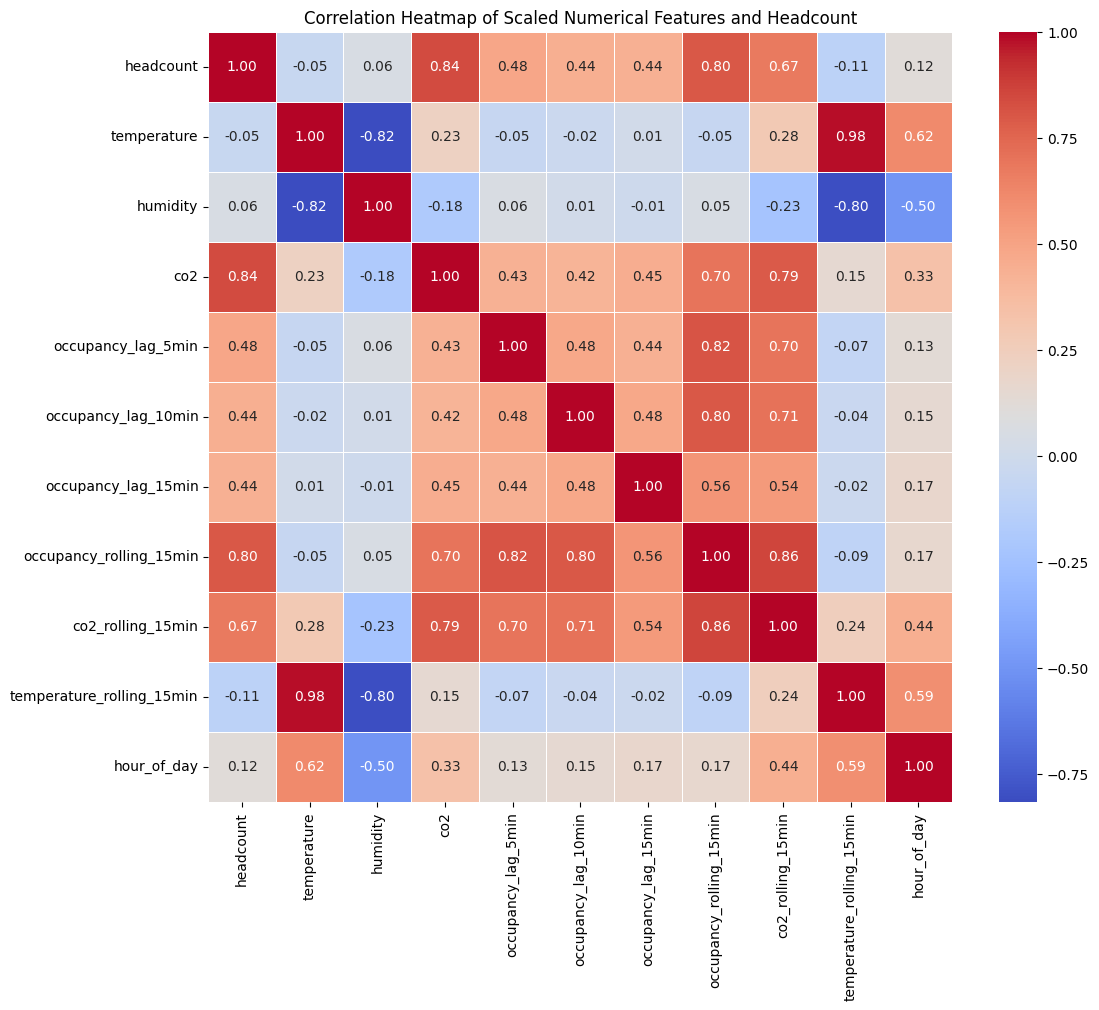

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the list of numerical columns for correlation, including the target 'headcount'
# Exclude 'timestamp', 'deviceid', 'floorspaceid', and 'day_of_week' (categorical)
correlation_cols = [
    'headcount', 'temperature', 'humidity', 'co2',
    'occupancy_lag_5min', 'occupancy_lag_10min', 'occupancy_lag_15min',
    'occupancy_rolling_15min', 'co2_rolling_15min', 'temperature_rolling_15min',
    'hour_of_day'
]

# Ensure all selected columns exist in the DataFrame
correlation_cols = [col for col in correlation_cols if col in df.columns]

# Calculate the correlation matrix
correlation_matrix = df[correlation_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Scaled Numerical Features and Headcount')
plt.show()

## **Model Development, Training, and Evaluation**

This section presents the complete machine learning pipeline for Predicting `headcount`. All preprocessing from previous section (encoding, scaling) is re-applied **inside scikit-learn pipelines** in this section — encoders and scalers are fitted only on the training data, ensuring there is no information leakage from the test set.

For each task, the workflow follows four consistent stages:
- **(a)** Feature selection and 80/20 train-test split
- **(b)** Baseline model training and diagnostic evaluation
- **(c)** Baseline model comparison
- **(d)** Hyperparameter tuning via Bayesian optimisation (Optuna TPE) with 5-fold cross-validation
- **(e)** Baseline vs tuned performance comparison and best model identification

### **Modelling Approach**
Since `headcount` is a continuous numerical variable, this is a **supervised regression problem**. Five model families are compared:

| # | Model | Type |
|---|---|---|
| 1 | Support Vector Machine (SVM) | Linear |
| 2 | Random Forest Regressor | Ensemble (Bagging) |
| 3 | Neural Network Regressor (MLP) | Deep learning |

Models are evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, **R² Score**, and **5-fold cross-validation R²**, to assess both accuracy and generalisation.